In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from adjustText import adjust_text
import os
os.chdir("../output/variable_embeddings/")

In [2]:
correlation_df = pd.read_csv("MIMIC_feature_imp_correlation_results.csv")
correlation_df = correlation_df[correlation_df["Type"]=="Actual"]
correlation_df.drop(columns="Type", inplace=True)
vis_df = pd.read_csv("MIMIC_variable_visualization_results.csv", index_col=0)
correlation_df = correlation_df.replace({"NF": "Neutropenic Fever"})
vis_df.rename(columns={"imp_mean": "Importance", "cosine_sim": "Cosine sim."}, inplace=True)
vis_df.rename(index={"label_nf": "Neutropenic Fever", "label_aplasia": "Aplasia"}, inplace=True)
aplasia_clust = vis_df[vis_df["cluster_id"]==0]
aplasia_clust = aplasia_clust[~aplasia_clust.index.duplicated(keep='first')]
aplasia_clust

,tSNE_1,tSNE_2,cluster_id,Importance,Cosine sim.
Hemoglobin,-1.897226,-0.443236,0,1.07,0.226480
Platelet Count,-2.680866,0.305781,0,1.74,0.469952
RDW,-1.409064,1.962976,0,1.56,0.257083
Red Blood Cells,-2.140735,-0.530177,0,2.05,0.340831
RDW-SD,0.062741,2.051343,0,1.13,0.253017
Alanine Aminotransferase (ALT),-0.819972,1.793511,0,1.01,0.289163
Albumin,-2.247896,1.154520,0,2.32,0.432700
Creatinine,-1.769712,1.141792,0,1.21,0.603515
Glucose,-2.016437,2.481461,0,2.87,0.300723
Urea Nitrogen,-1.626548,-0.416698,0,2.81,0.333383


Text(0.0, 1.0, 'c')

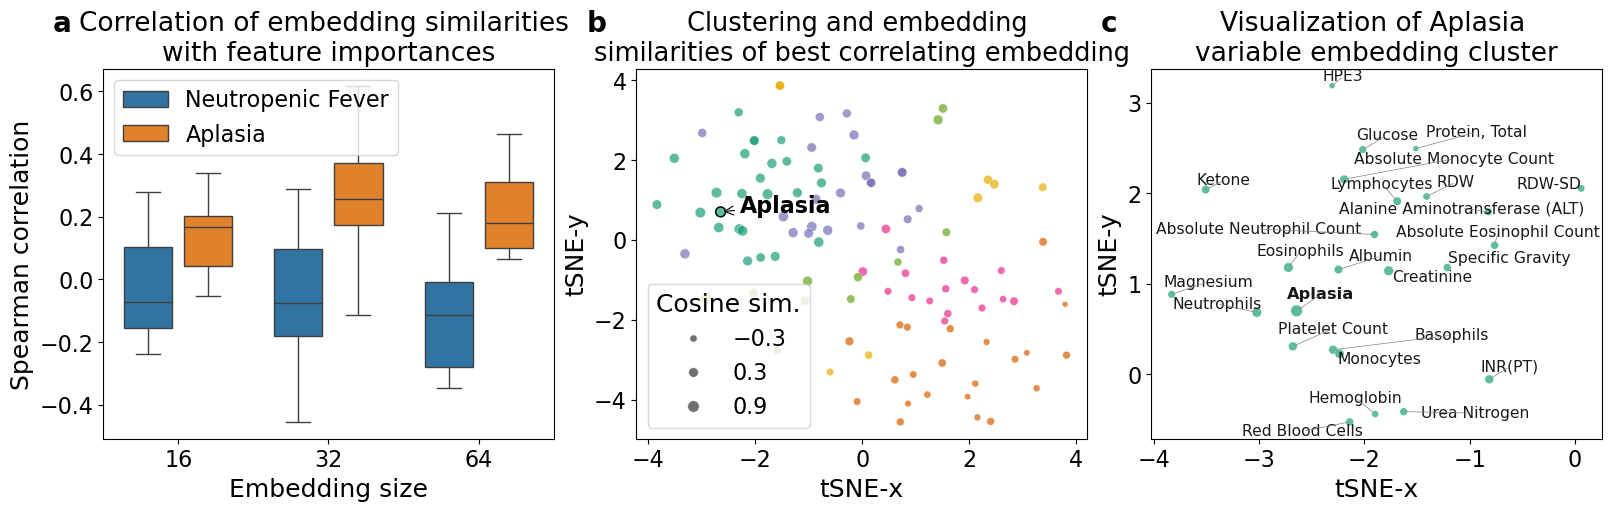

In [4]:
mosaic = [
['a', 'b', 'c'],
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(16,5), layout='constrained')

offset = transforms.ScaledTranslation(-36/72, 27/72, fig.dpi_scale_trans)
labelfontsize = 20
titlefontsize = 20
ticklabelsize = 16
xylabelsize = 18
legendfontsize = 16
legendtitlefontsize = 18
pvalfontsize = 18

sns.boxplot(data=correlation_df, x='dim', y='corr', hue='target', 
        dodge=True, ax=axes['a'],
        palette=sns.color_palette("tab10", 2), legend=True, gap=0.2)
axes['a'].set_xlabel('Embedding size', fontsize=xylabelsize)
axes['a'].set_ylabel('Spearman correlation', fontsize=xylabelsize)
axes['a'].set_title('Correlation of embedding similarities \nwith feature importances', fontsize=titlefontsize-1)
axes['a'].tick_params(labelsize=ticklabelsize)
axes['a'].legend(fontsize=legendfontsize)
axes['a'].text(0.0, 1.0, 'a', transform=axes['a'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.scatterplot(data=vis_df, x='tSNE_1', y='tSNE_2', hue='cluster_id', size="Cosine sim.",
        ax=axes['b'], alpha=0.7, edgecolor="w",
        palette=sns.color_palette("Dark2", 6), legend=True)
axes['b'].set_xlabel('tSNE-x', fontsize=xylabelsize)
axes['b'].set_ylabel('tSNE-y', fontsize=xylabelsize)
axes['b'].set_title('Clustering and embedding \nsimilarities of best correlating embedding', fontsize=titlefontsize-1.5)
axes['b'].tick_params(labelsize=ticklabelsize)
axes['b'].text(0.0, 1.0, 'b', transform=axes['b'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# 3. Annotate the "Aplasia" point
# 2. Overlay "Aplasia" as an empty circle
if "Aplasia" in vis_df.index:
    point = vis_df.loc["Aplasia"]
    
    # We use the raw matplotlib scatter to get the 'empty' effect
    axes['b'].scatter(
        point['tSNE_1'], point['tSNE_2'],
        s=50,              # Adjust size to match your "Importance" scale
        facecolors='none',  # Makes it empty/transparent
        edgecolors='black', # High contrast border
        linewidth=1.0,
        zorder=5            # Ensures it sits on top of other points
    )
    
    # 3. Annotate the "Aplasia" point
    axes['b'].annotate(
        "Aplasia", 
        xy=(point['tSNE_1'], point['tSNE_2']),
        xytext=(14, 0), 
        textcoords="offset points",
        fontsize=ticklabelsize, 
        fontweight='bold',
        arrowprops=dict(arrowstyle="->", color='black', lw=0.8)
    )

handles, labels = axes['b'].get_legend_handles_labels()

keep = ['-0.3', '0.3', '0.9']
filtered = [(h, l) for index, (h, l) in enumerate(zip(handles, labels)) if index%2==0 and index>6]

handles_f, labels_f = zip(*filtered)

axes['b'].legend(handles_f, labels_f, title="Cosine sim.",
                 loc='best', fontsize=legendfontsize, title_fontsize=legendtitlefontsize)
    
sns.scatterplot(
    data=aplasia_clust,
    x='tSNE_1',
    y='tSNE_2',
    size="Cosine sim.",
    ax=axes['c'],
    alpha=0.7,
    edgecolor="w",
    legend=False,
    color=sns.color_palette("Dark2", 6)[0]
)

texts = []

for label, row in aplasia_clust.iterrows():
    txt = axes['c'].text(
        row['tSNE_1'],
        row['tSNE_2'],
        str(label),
        fontsize=ticklabelsize*0.7+0.5 if str(label)=="Aplasia" else ticklabelsize*0.7,
        ha='center',
        va='bottom',
        alpha=0.9,
        fontweight='bold' if str(label) == "Aplasia" else 'normal'
    )
    texts.append(txt)

adjust_text(
    texts,
    ax=axes['c'],
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle="-", color='gray', lw=0.5)
)

axes['c'].set_xlabel('tSNE-x', fontsize=xylabelsize)
axes['c'].set_ylabel('tSNE-y', fontsize=xylabelsize)
axes['c'].set_title('Visualization of Aplasia \nvariable embedding cluster', fontsize=titlefontsize-1)
axes['c'].tick_params(labelsize=ticklabelsize)

axes['c'].text(
    0.0, 1.0, 'c',
    transform=axes['c'].transAxes + offset,
    fontsize=labelfontsize,
    fontweight='bold'
)

#plt.savefig("variable_results.pdf")